<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/YIN_TWM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Harmonic Model

### From Sinusoidal Model

Sinusoidal model accepts any peaks anywhere **including noise and window artifacts**.

for r in number of Harmonics($r = 1, 2, ..., nH$), $f_r = r{f_0}$

Sinusoidal: $x[n] ≈ ∑^R_{r = 1}A_r[n]cos(2πf_r[n]n + \phi_r[n]$)

Harmonic: $x[n] ≈ ∑^R_{r = 1}A_r[n]cos(2πrf_0[n]n + \phi_r[n]$)

### $f_0$ (pitch) detection (search problem)

#### YIN Algorithm (Detection in the time domain)

**Autocorrelation** with tapering: $$r_x[l] = ∑_{n=0}^{N-1-l}x[n]x[n+l]: l(lag) = 0, 1, ..., N-1$$ measures how a signal resembles with lagged itself =>maximum at $l = 0$, sensitive to noise, octave errors

name YIN was Named after the Taoist concept — the complementary opposite of autocorrelation.

**[YIN Algorithm](http://audition.ens.fr/adc/pdf/2002_JASA_YIN.pdf)** measures difference instead of similarity with:
$$d[l] = ∑_{n=0}^{N-1-l}(x[n] - x[n+l])^2$$
expanding it gives $$d[l] = r_x[0] + r_x[0] - 2r_x[l]$$
cumulative mean normalized difference $$
d'[l]=
\begin{cases}
1, \text{when } l = 0\\\frac{
d[l]}{\frac{1}{l}∑_{j=1}^{l}d[l]} \text{ otherwise}\\
\end{cases}
$$
which removes the favor of short lags (bias)

##### Demo (Simplified YIN derived from [librosa.yin](https://librosa.org/doc/main/_modules/librosa/core/pitch.html#yin))

In [48]:
# audio
!pip install sms-tools
!git clone https://github.com/MTG/sms-tools-materials.git
# need session reboot

fatal: destination path 'sms-tools-materials' already exists and is not an empty directory.


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from smstools.models.utilFunctions import wavread
import soundfile as sf
import scipy
import scipy.fft as fft

In [50]:
def _abs2(x):
    """Squared magnitude (replaces util.abs2)."""
    if np.iscomplexobj(x):
        return x.real ** 2 + x.imag ** 2
    return x ** 2

def Autocorrelate(y: np.ndarray, max_size=None, axis: int = -1):
    if max_size is None:
        max_size = y.shape[axis]

    max_size = int(min(max_size, y.shape[axis]))
    real = not np.iscomplexobj(y)

    n_pad = scipy.fft.next_fast_len(2 * y.shape[axis] - 1, real=real)

    if real:
        powspec = _abs2(fft.rfft(y, n=n_pad, axis=axis))
        autocorr = fft.irfft(powspec, n=n_pad, axis=axis)
    else:
        powspec = _abs2(fft.fft(y, n=n_pad, axis=axis))
        autocorr = fft.ifft(powspec, n=n_pad, axis=axis)

    subslice = [slice(None)] * autocorr.ndim
    subslice[axis] = slice(max_size)

    return autocorr[tuple(subslice)]

def avoid_zero_div(x):
    x = np.asarray(x)
    if np.issubdtype(x.dtype, np.floating) or np.issubdtype(x.dtype, np.complexfloating):
        dtype = x.dtype
    else:
        dtype = np.dtype(np.float32)
    return np.finfo(dtype).tiny

def normalized_difference(y_frames: np.ndarray,
                          min_period: int,
                          max_period: int):
    acf_frames = Autocorrelate(y_frames, max_size=max_period + 1, axis=-2)
    yin_frames = np.zeros_like(acf_frames[..., : max_period + 1, :])
    yin_frames[..., 0, :] = 0

    for k in range(1, max_period + 1):
        yin_frames[..., k, :] = (
            2 * (acf_frames[..., 0:1, :] - acf_frames[..., k : k + 1, :])
            + yin_frames[..., k - 1 : k, :]
        )

    yin_numerator = yin_frames[..., min_period : max_period + 1, :]

    k = slice(1, max_period + 1)
    shape = [1] * yin_frames.ndim
    shape[-2] = max_period  # axis -2 gets the lag dimension
    k_range = np.arange(1, max_period + 1).reshape(shape)

    cumulative_mean = (
        np.cumsum(yin_frames[..., k, :], axis=-2) / k_range
    )
    yin_denominator = cumulative_mean[..., min_period - 1 : max_period, :]

    yin_frames = yin_numerator / (
        yin_denominator + avoid_zero_div(yin_denominator))
    return yin_frames

def parabolic_interpolation(x: np.ndarray,
                            axis: int = -2):
    # Allocate the output array and rotate target axis
    x_s = x.swapaxes(-1, axis)
    shifts = np.zeros_like(x)
    shifts_s = shifts.swapaxes(-1, axis)

    alpha = x_s[..., :-2, :]   # x[k-1] ------@
    beta  = x_s[..., 1:-1, :]  # x[k]   ----------@
    gamma = x_s[..., 2:, :]    # x[k+1] -------@

    a = alpha + gamma - 2 * beta
    b = (gamma - alpha) / 2
    denom = np.where(np.abs(b) < np.abs(a), a, np.ones_like(a))
    shift = np.where(np.abs(b) < np.abs(a), -b / denom, 0.0)
    pad_shape = list(shifts_s.shape)
    pad_shape[-2] = 1
    pad = np.zeros(pad_shape, dtype=shift.dtype)
    shifts_s[..., 1:-1, :] = shift
    shifts_s[..., :1, :]   = pad
    shifts_s[..., -1:, :]  = pad

    return shifts

def frame(x:np.ndarray,
          frame_length,
          hop_length):
    x = np.array(x, copy = False, subok = False)
    out_strides = x.strides + tuple([x.strides[-1]])
    x_shape_trimmed = list(x.shape)
    x_shape_trimmed[-1] -= frame_length - 1
    out_shape = tuple(x_shape_trimmed) + tuple([frame_length])
    xw = np.lib.stride_tricks.as_strided(
        x, strides=out_strides, shape=out_shape, subok=False, writeable=False
    )
    xw = np.moveaxis(xw, -1, -2)

    slices = [slice(None)] * xw.ndim
    slices[-1] = slice(0, None, hop_length)

    return xw[tuple(slices)]
def simple_yin(x: np.ndarray,
               fmin: float,
               fmax: float,
               sr: float):
    min_period = int(np.floor(sr / fmax))

    frame_time = 100 # ms
    frame_length = int(sr * frame_time / 1000) # frame samples in ms
    max_period = min(int(np.ceil(sr / fmin)), frame_length -1)

    hop_length = int(frame_length/4)
    y_frames = frame(x, frame_length=frame_length, hop_length=hop_length)

    yin_frames = normalized_difference(y_frames, min_period, max_period)
    parabolic_shifts = parabolic_interpolation(yin_frames)

    yin_period_idx = np.argmin(yin_frames, axis=-2, keepdims=True)
    yin_period = (
        min_period
        + yin_period_idx
        + np.take_along_axis(parabolic_shifts, yin_period_idx, axis=-2)
    )
    f0: np.ndarray = sr / yin_period.squeeze(axis=-2)
    return f0

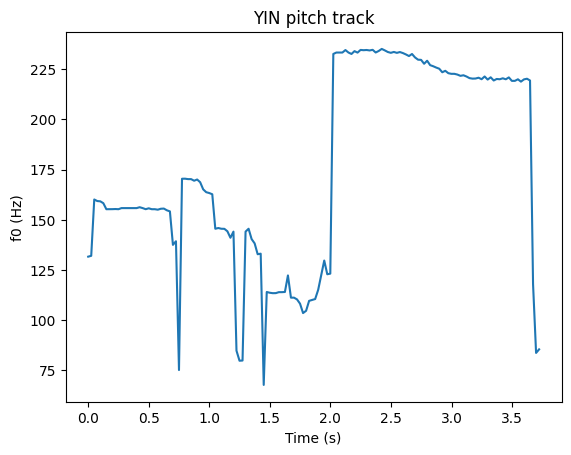

In [51]:
path =  "/content/sms-tools-materials/sounds/piano.wav"
x, sr = sf.read(path)

# If stereo, take one channel
if x.ndim > 1:
    x = x[:, 0]
ipd.display(ipd.Audio(x, rate=sr))
# YIN f0 detection
fmin = 65 # around C2
fmax = 2093 # around C7
f0 = simple_yin(x, fmin=fmin, fmax=fmax, sr=sr)

# Reconstruct time axis from hop_length (must match what simple_yin used)
frame_length = int(sr * 100 / 1000)   # 100 ms frames
hop_length   = int(frame_length / 4)  # as in simple_yin

n_frames = f0.shape[-1]
times = np.arange(n_frames) * hop_length / sr

import matplotlib.pyplot as plt
plt.plot(times, f0)
plt.xlabel('Time (s)')
plt.ylabel('f0 (Hz)')
plt.title('YIN pitch track')
plt.show()

In [52]:
# --- Spectrogram ---
n_fft        = frame_length          # match window size to YIN frames
spec_hop     = hop_length            # same hop so time axes align
window       = np.hanning(n_fft)

# Manual STFT magnitude
num_frames = 1 + (len(x) - n_fft) // spec_hop
S = np.zeros((n_fft // 2 + 1, num_frames))
for i in range(num_frames):
    chunk = x[i * spec_hop : i * spec_hop + n_fft] * window
    S[:, i] = np.abs(np.fft.rfft(chunk))

S_db        = 20 * np.log10(S + 1e-9)
spec_times  = np.arange(num_frames) * spec_hop / sr
spec_freqs  = np.fft.rfftfreq(n_fft, d=1.0 / sr)

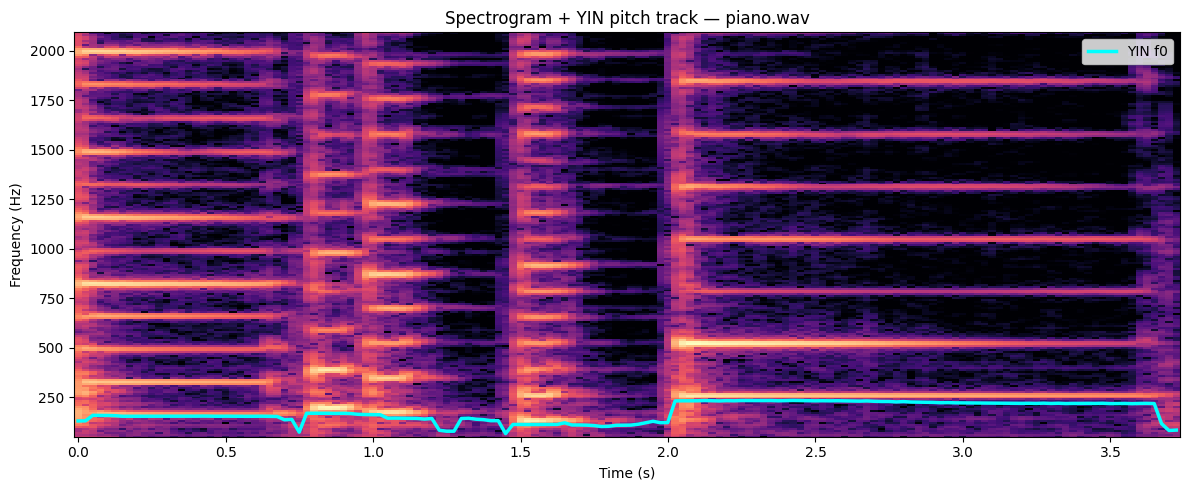

In [53]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.pcolormesh(
    spec_times, spec_freqs, S_db,
    shading="auto",
    cmap="magma",
    vmin=S_db.max() - 80,   # 80 dB dynamic range
    vmax=S_db.max(),
)

ax.plot(times, f0.squeeze(), color="cyan", linewidth=2.5, label="YIN f0")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram + YIN pitch track — piano.wav")
ax.set_ylim(fmin * 0.8, fmax)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Synthesize

In [54]:
# a time axis
# This maps each f0 value to its exact time in seconds
frame_times = np.arange(len(f0)) * spec_hop / sr

# 2. Create a high-resolution time axis for the actual audio samples
# The total length is the number of frames multiplied by the hop size
total_samples = len(f0) * spec_hop
sample_times = np.arange(total_samples) / sr

# 3. Interpolate the f0 array
# We need a frequency value for *every single sample*, not just every frame
f0_interpolated = np.interp(sample_times, frame_times, f0)

# 4. Calculate the continuous phase
# Mathematically: phase[n] = phase[n-1] + 2π * (f0[n] / sr)
# We achieve this efficiently using cumulative sum (cumsum)
phase = 2 * np.pi * np.cumsum(f0_interpolated) / sr

# 5. Synthesize the pitch waveform
# Generate a pure sine wave from the continuous phase
pitch_signal = np.sin(phase)
ipd.display(ipd.Audio(pitch_signal, rate=sr))

#### Two-Way Mismatch (Spectral Domain)